# A Data-Driven Player Recruitment and Replacement System for Elite Football
### Identifying Playing Style Similarity and Market Value Efficiency Using Performance Analytics

**MSc Data Science Dissertation — Analytical Pipeline**

Runs on the peer-reviewed **Pappalardo et al. (2019)** public soccer-logs
dataset (Wyscout): all Big Five European league matches of **2017-18**,
with every per-player metric **derived from raw match events** by
`derive_pappalardo.py`.

| Section | Stage |
|---|---|
| 1 | Setup |
| 2 | Data loading and column mapping |
| 3 | Market values (optional) |
| 4 | Cleaning and per-90 normalisation |
| 5 | Feature engineering — five style dimensions |
| 6 | Correlation analysis and PCA |
| 7 | Clustering — tactical archetypes |
| 8 | Recruitment engine — similarity and value efficiency |
| 9 | Summary |

---

### Note on the data source

The dataset is the public soccer-logs collection of Pappalardo et al. (2019),
published in *Nature Scientific Data* (DOI 10.1038/s41597-019-0247-7) and
hosted on figshare (DOI 10.6084/m9.figshare.c.4415000). It contains every
spatio-temporal match event for the complete 2017-18 season of the Premier
League, La Liga, Bundesliga, Serie A and Ligue 1 (1,826 matches, ~3.1M events).

All player metrics here are **derived from the raw events** (definitions in
`derive_pappalardo.py` and Chapter 3): minutes from lineups and substitutions;
key passes, assists and interceptions from Wyscout tags; progressive passes
and penalty-area entries from event coordinates. One definitional note:
Wyscout's key-pass tag marks clear chances and is stricter than Opta's, so
counts are lower than FBref's but internally consistent — which is what
similarity analysis requires.


## 1. Setup

In [1]:
import re, unicodedata, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics.pairwise import cosine_similarity
import plotly.express as px
import plotly.graph_objects as go

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None); pd.set_option("display.width", 220)
plt.rcParams.update({"figure.dpi":110, "axes.spines.top":False, "axes.spines.right":False,
                     "axes.grid":True, "grid.alpha":0.3})
for d in ["data/raw","data/processed","outputs"]:
    Path(d).mkdir(parents=True, exist_ok=True)
print("Setup complete.")


Setup complete.


## 2. Data Loading

Run the derivation first (see README): it reads the figshare files and writes
`data/processed/players_derived.csv` — one row per player with season counts.
This notebook loads that file.


In [2]:
DATA_PATH   = "data/processed/players_derived.csv"
SEASON      = "2017-18"
POSITIONS   = ["MF"]
MIN_MINUTES = 900        # ten full matches


In [3]:
if not Path(DATA_PATH).exists():
    raise FileNotFoundError(
        f"{DATA_PATH} not found.\n"
        "Run the derivation first:\n"
        "  python derive_pappalardo.py --data-dir raw --out data/processed/players_derived.csv\n"
        "See README for how to obtain the figshare files.")

df = pd.read_csv(DATA_PATH)
print(f"Loaded: {df.shape[0]} players x {df.shape[1]} columns (derived from raw events)")
df["season"] = SEASON
df.head(3)


Loaded: 2568 players x 33 columns (derived from raw events)


,player_id,player,position,birth_date,league,minutes,matches,passes,passes_accurate,key_passes,assists,smart_passes,passes_into_penalty_area,progressive_passes,progressive_pass_distance,crosses,long_passes,shots,shots_on_target,goals,dribbles_won,dribbles_attempted,accelerations,touches_att_pen_area,tackles_won,tackles_attempted,interceptions,clearances,aerials_won,age,season,passes_pct,dribble_success_pct
0,8192,M. Olsson,DF,1988-05-17,Premier League,3154.0,36.0,1242.0,918.0,6.0,1.0,3.0,52.0,161.0,6479.55,171.0,122.0,20.0,2.0,0.0,86.0,165.0,42.0,36.0,33.0,166.0,135.0,65.0,54.0,29,2017-18,73.9,52.1
1,415747,J. Simpson,DF,1997-01-08,Premier League,72.0,1.0,6.0,6.0,0.0,0.0,0.0,0.0,0.0,28.35,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,6.0,4.0,2.0,0.0,20,2017-18,100.0,NaN
2,415748,J. Tymon,DF,1999-05-22,Premier League,163.0,3.0,81.0,68.0,0.0,0.0,0.0,0.0,7.0,300.30,3.0,5.0,0.0,0.0,0.0,1.0,4.0,1.0,0.0,2.0,15.0,4.0,3.0,0.0,18,2017-18,84.0,25.0


### 2b. Metric availability

Confirm the metrics exist before building features on them.


In [4]:
NEEDED = ["key_passes","smart_passes","assists","passes_into_penalty_area",
          "passes_pct","progressive_passes","progressive_pass_distance",
          "dribbles_won","accelerations","touches_att_pen_area","dribble_success_pct",
          "shots","shots_on_target","goals",
          "tackles_won","interceptions","clearances","aerials_won"]
ok = 0
for c in NEEDED:
    if c in df.columns and df[c].notna().any():
        print(f"  {c:32s} YES  ({100*df[c].notna().sum()/len(df):.0f}% non-null)")
        ok += 1
    else:
        print(f"  {c:32s} MISSING")
print(f"\n{ok}/{len(NEEDED)} metrics available")
if ok < 15:
    raise RuntimeError("Too few metrics — check COLUMN_MAP against df.columns.tolist()")


  key_passes                       YES  (100% non-null)
  smart_passes                     YES  (100% non-null)
  assists                          YES  (100% non-null)
  passes_into_penalty_area         YES  (100% non-null)
  passes_pct                       YES  (100% non-null)
  progressive_passes               YES  (100% non-null)
  progressive_pass_distance        YES  (100% non-null)
  dribbles_won                     YES  (100% non-null)
  accelerations                    YES  (100% non-null)
  touches_att_pen_area             YES  (100% non-null)
  dribble_success_pct              YES  (94% non-null)
  shots                            YES  (100% non-null)
  shots_on_target                  YES  (100% non-null)
  goals                            YES  (100% non-null)
  tackles_won                      YES  (100% non-null)
  interceptions                    YES  (100% non-null)
  clearances                       YES  (100% non-null)
  aerials_won                      YES  (100% non

## 3. Market values (optional)

Place a CSV at `data/raw/values.csv` with columns `player,market_value_eur_m`
to enable the value-efficiency score (RQ3).

Without it, clustering and similarity still work; only value-efficiency is
disabled. Names are matched exactly, then fuzzy-matched (token-sort ratio >= 85).
Characters Unicode does not decompose are mapped explicitly, so
`Ødegaard` -> `odegaard`, not `degaard`.


In [5]:
SPECIAL = str.maketrans({"Ø":"O","ø":"o","Đ":"D","đ":"d","Ł":"L","ł":"l","ß":"ss",
                         "Æ":"AE","æ":"ae","Œ":"OE","œ":"oe","Þ":"Th","þ":"th",
                         "İ":"I","ı":"i","Ð":"D","ð":"d"})

def norm_name(n):
    if not isinstance(n, str): return ""
    a = unicodedata.normalize("NFKD", n.translate(SPECIAL)) \
                   .encode("ascii","ignore").decode("ascii").lower()
    return re.sub(r"\s+", " ", re.sub(r"[^\w\s-]", "", a)).strip()

vp = Path("data/raw/values.csv")
if vp.exists():
    vals = pd.read_csv(vp)
    vals["_n"] = vals["player"].apply(norm_name)
    lookup = (vals.dropna(subset=["market_value_eur_m"])
                  .drop_duplicates("_n").set_index("_n")["market_value_eur_m"].to_dict())
    try:
        from rapidfuzz import process, fuzz
        keys = list(lookup); fuzzy = True
    except ImportError:
        fuzzy = False; print("rapidfuzz not installed — exact matching only")
    out, how = [], []
    for p in df["player"]:
        n = norm_name(p)
        if n in lookup:
            out.append(lookup[n]); how.append("exact")
        elif fuzzy:
            r = process.extractOne(n, keys, scorer=fuzz.token_sort_ratio, score_cutoff=85)
            if r: out.append(lookup[r[0]]); how.append(f"fuzzy_{int(r[1])}")
            else: out.append(np.nan); how.append("unmatched")
        else:
            out.append(np.nan); how.append("unmatched")
    df["market_value_eur_m"] = out
    df["value_match_method"] = how
    n_ok = df["market_value_eur_m"].notna().sum()
    print(f"Values matched: {n_ok}/{len(df)} ({100*n_ok/len(df):.1f}%)")
    print("Spot-check the fuzzy matches in data/raw/values.csv — a bad match")
    print("silently assigns the wrong player's value.")
else:
    df["market_value_eur_m"] = np.nan
    print("No data/raw/values.csv — proceeding without market values.")
    print("Clustering and similarity work; value-efficiency (RQ3) is disabled.")

HAS_VALUES = df["market_value_eur_m"].notna().any()


rapidfuzz not installed — exact matching only
Values matched: 577/2568 (22.5%)
Spot-check the fuzzy matches in data/raw/values.csv — a bad match
silently assigns the wrong player's value.


## 4. Cleaning and per-90 normalisation

Goalkeepers are excluded (their metrics are incomparable). A 900-minute
threshold removes players whose per-90 rates would be unstable — the
convention in the analytics literature.

Per-90 normalisation is the key step for fair comparison: a player with 10
goals in 900 minutes is twice as prolific as one with 10 in 1,800. Percentage
metrics (`passes_pct`) are already rates and are left untouched.


In [6]:
df = df[~df["position"].astype(str).str.upper().str.startswith("GK")]
df = df[df["position"].astype(str).str.contains("|".join(POSITIONS), case=False, na=False)]

for c in NEEDED + ["minutes","goals","assists","carries","touches"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = df[df["minutes"].fillna(0) >= MIN_MINUTES].reset_index(drop=True)
print(f"Midfielders with {MIN_MINUTES}+ minutes: {len(df)}")
print(f"By league: {df['league'].value_counts().to_dict()}")

COUNT_COLS = ["key_passes","smart_passes","assists","passes_into_penalty_area",
              "progressive_passes","progressive_pass_distance","crosses",
              "dribbles_won","accelerations","touches_att_pen_area",
              "shots","shots_on_target","goals",
              "tackles_won","interceptions","clearances","aerials_won"]

n90 = df["minutes"] / 90
for c in COUNT_COLS:
    if c in df.columns:
        df[f"{c}_p90"] = (df[c] / n90).round(3)

print(f"Created {len([c for c in df.columns if c.endswith('_p90')])} per-90 columns")
df[["player","league","minutes","key_passes_p90","progressive_passes_p90","tackles_won_p90"]].head()


Midfielders with 900+ minutes: 590
By league: {'La Liga': 126, 'Premier League': 121, 'Ligue 1': 119, 'Serie A': 113, 'Bundesliga': 111}
Created 17 per-90 columns


,player,league,minutes,key_passes_p90,progressive_passes_p90,tackles_won_p90
0,S. Clucas,Premier League,2043.0,0.044,3.172,1.101
1,R. Loftus-Cheek,Premier League,1875.0,0.240,4.320,1.200
2,C. Eriksen,Premier League,3226.0,0.697,8.035,0.809
3,A. Lennon,Premier League,1919.0,0.094,2.110,0.844
4,J. Guðmunds­son,Premier League,2838.0,0.444,2.632,0.793


## 5. Feature engineering — five style dimensions

The per-90 metrics are numerous and correlated. They are condensed into five
interpretable style dimensions, each a weighted blend of its components,
MinMax-scaled to 0-1. Weights are stated explicitly so the model is
transparent and auditable.

| Dimension | Components (all derived from raw events) |
|---|---|
| Creativity | key passes, smart passes, assists, passes into penalty area |
| Distribution | pass completion %, progressive pass distance, progressive passes |
| Ball-carrying | dribbles won, accelerations, box touches, dribble success % |
| Defensive work | tackles won, interceptions, clearances, aerial duels won |
| Goal threat | shots, shots on target, goals |

xG is not available in this dataset (it predates public xG provision); goal
threat therefore uses realised shooting volume, accuracy and goals — a
documented substitution.


In [7]:
STYLE_DIMENSIONS = {
    "creativity_score": {
        "key_passes_p90":0.30, "smart_passes_p90":0.25, "assists_p90":0.20,
        "passes_into_penalty_area_p90":0.25},
    "distribution_score": {
        "passes_pct":0.35, "progressive_pass_distance_p90":0.35,
        "progressive_passes_p90":0.30},
    "ball_carrying_score": {
        "dribbles_won_p90":0.35, "accelerations_p90":0.25,
        "touches_att_pen_area_p90":0.20, "dribble_success_pct":0.20},
    "defensive_score": {
        "tackles_won_p90":0.30, "interceptions_p90":0.30,
        "clearances_p90":0.20, "aerials_won_p90":0.20},
    "goal_threat_score": {
        "shots_p90":0.35, "shots_on_target_p90":0.30, "goals_p90":0.35},
}

def engineer_style(df):
    df = df.copy()
    for dim, comps in STYLE_DIMENSIONS.items():
        avail = {c:w for c,w in comps.items() if c in df.columns}
        if not avail:
            print(f"  WARNING: no components for {dim}"); continue
        if len(avail) < len(comps):
            print(f"  {dim}: using {len(avail)}/{len(comps)} components")
        total = sum(avail.values())
        parts = [MinMaxScaler().fit_transform(df[[c]].fillna(0)).flatten() * (w/total)
                 for c, w in avail.items()]
        df[dim] = np.stack(parts, axis=1).sum(axis=1).round(4)
    return df

df = engineer_style(df)
STYLE_SCORES = [d for d in STYLE_DIMENSIONS if d in df.columns]
df.to_csv("data/processed/players_processed.csv", index=False)
print(f"\nBuilt {len(STYLE_SCORES)} style dimensions")
df[["player","league"] + STYLE_SCORES].head(10)



Built 5 style dimensions

,player,league,creativity_score,distribution_score,ball_carrying_score,defensive_score,goal_threat_score
0,S. Clucas,Premier League,0.0433,0.3384,0.1175,0.2826,0.1958
1,R. Loftus-Cheek,Premier League,0.2293,0.3839,0.5941,0.3194,0.2309
2,C. Eriksen,Premier League,0.4734,0.5071,0.2234,0.1630,0.5778
3,A. Lennon,Premier League,0.1204,0.1693,0.3015,0.1940,0.0977
4,J. Guðmunds­son,Premier League,0.2664,0.1907,0.3036,0.2098,0.2936
5,J. Livermore,Premier League,0.1620,0.3842,0.1683,0.3264,0.1003
6,A. Pritchard,Premier League,0.3492,0.2333,0.2803,0.1732,0.2567
7,R. Pereyra,Premier League,0.2386,0.4028,0.3627,0.1228,0.4279
8,G. Wijnaldum,Premier League,0.0887,0.4493,0.2227,0.2518,0.1926
9,E. Can,Premier League,0.1959,0.5571,0.3259,0.4803,0.2341


## 6. Correlation analysis and PCA

Redundant metrics (|r| > 0.85) would distort clustering by double-counting the
same underlying construct. PCA then reveals how much of the variance the
dimensions share.


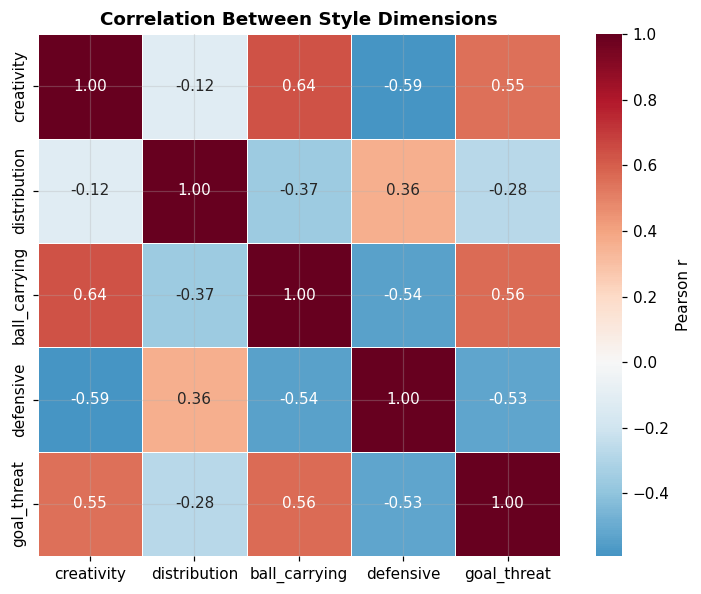

Redundant pairs (|r| > 0.85): none — all five dimensions retained


In [8]:
corr = df[STYLE_SCORES].corr()
fig, ax = plt.subplots(figsize=(7,5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True,
            linewidths=0.5, cbar_kws={"label":"Pearson r"}, ax=ax,
            xticklabels=[s.replace("_score","") for s in STYLE_SCORES],
            yticklabels=[s.replace("_score","") for s in STYLE_SCORES])
ax.set_title("Correlation Between Style Dimensions", fontweight="bold")
plt.tight_layout(); plt.savefig("outputs/correlation_heatmap.png", bbox_inches="tight"); plt.show()

redundant = [(corr.columns[i], corr.columns[j], round(corr.iloc[i,j],3))
             for i in range(len(corr)) for j in range(i+1,len(corr))
             if abs(corr.iloc[i,j]) > 0.85]
print("Redundant pairs (|r| > 0.85):", redundant or "none — all five dimensions retained")


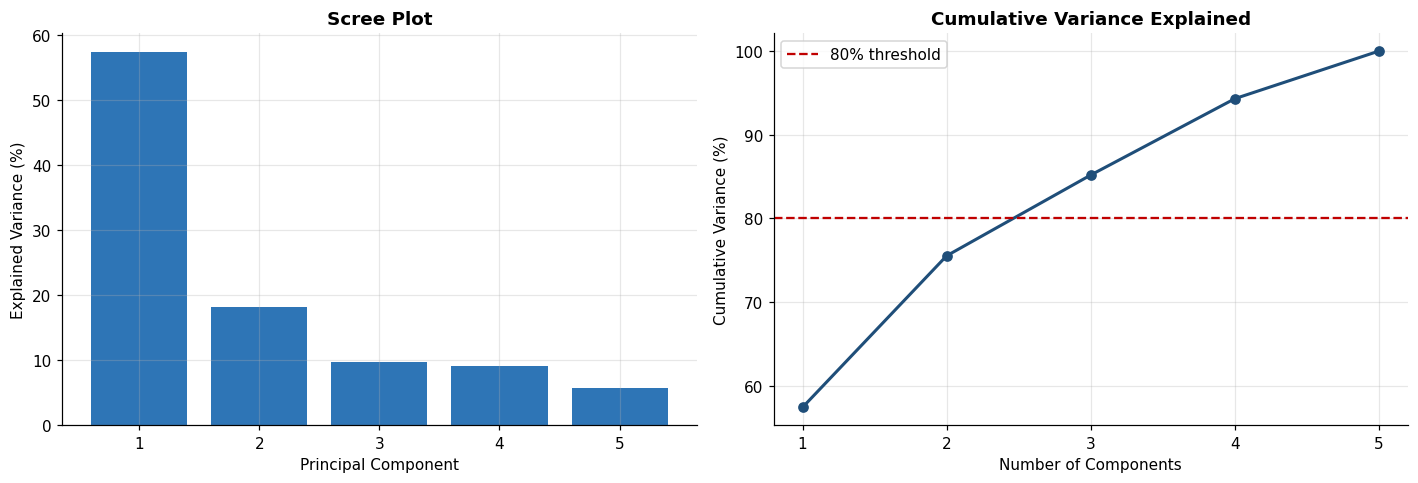

3 components explain 85.2% of variance

Component loadings:


,PC1,PC2,PC3
creativity,0.475,0.427,-0.233
distribution,-0.289,0.896,-0.001
ball_carrying,0.495,0.022,0.110
defensive,-0.479,0.018,0.610
goal_threat,0.465,0.116,0.749


In [9]:
X = StandardScaler().fit_transform(df[STYLE_SCORES].values)
pca = PCA(random_state=42).fit(X)
evr = pca.explained_variance_ratio_; cum = np.cumsum(evr)

fig, (a,b) = plt.subplots(1,2, figsize=(13,4.5))
a.bar(range(1,len(evr)+1), evr*100, color="#2E75B6")
a.set_xlabel("Principal Component"); a.set_ylabel("Explained Variance (%)")
a.set_title("Scree Plot", fontweight="bold"); a.set_xticks(range(1,len(evr)+1))
b.plot(range(1,len(cum)+1), cum*100, "o-", color="#1F4E79", lw=2)
b.axhline(80, color="#C00000", ls="--", label="80% threshold")
b.set_xlabel("Number of Components"); b.set_ylabel("Cumulative Variance (%)")
b.set_title("Cumulative Variance Explained", fontweight="bold")
b.set_xticks(range(1,len(cum)+1)); b.legend()
plt.tight_layout(); plt.savefig("outputs/pca_scree.png", bbox_inches="tight"); plt.show()

n80 = int(np.argmax(cum >= 0.80) + 1)
print(f"{n80} components explain {cum[n80-1]*100:.1f}% of variance")
print("\nComponent loadings:")
pd.DataFrame(pca.components_[:3].T, index=[s.replace("_score","") for s in STYLE_SCORES],
             columns=["PC1","PC2","PC3"]).round(3)


## 7. Clustering — discovering tactical archetypes

Addresses **RQ1**: can players be grouped into meaningful tactical archetypes
from public data alone?


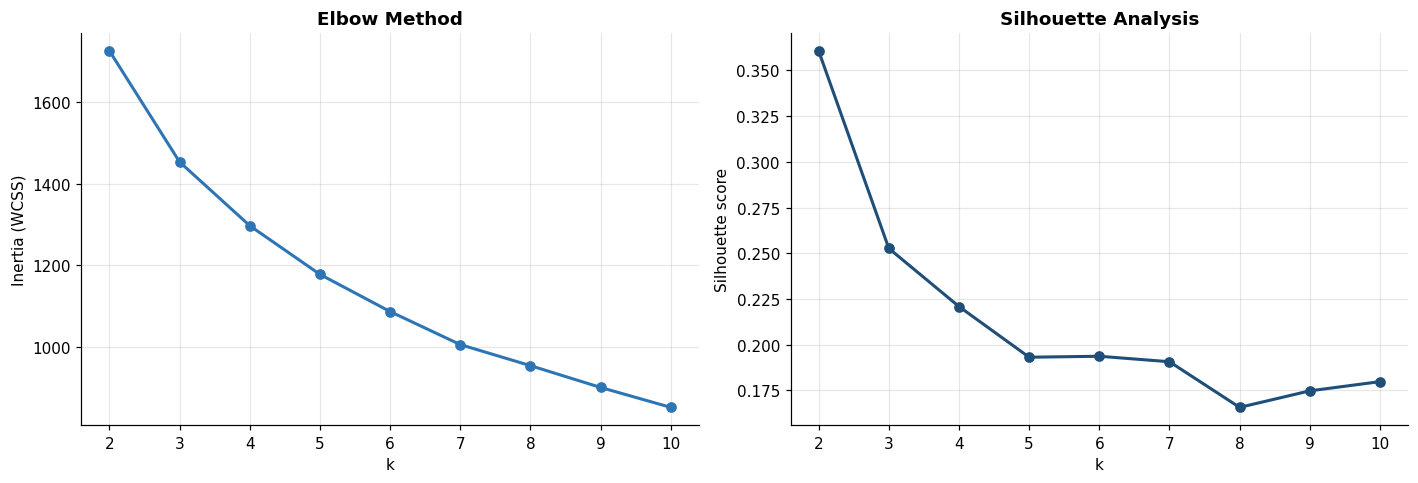

  k=2: silhouette 0.361
  k=3: silhouette 0.253
  k=4: silhouette 0.221
  k=5: silhouette 0.193
  k=6: silhouette 0.194
  k=7: silhouette 0.191
  k=8: silhouette 0.166
  k=9: silhouette 0.175
  k=10: silhouette 0.180


In [10]:
ks = list(range(2, 11))
inertias, sils = [], []
for k in ks:
    km = KMeans(k, random_state=42, n_init=10)
    lab = km.fit_predict(X)
    inertias.append(km.inertia_); sils.append(silhouette_score(X, lab))

fig, (a,b) = plt.subplots(1,2, figsize=(13,4.5))
a.plot(ks, inertias, "o-", color="#2E75B6", lw=2)
a.set_xlabel("k"); a.set_ylabel("Inertia (WCSS)"); a.set_title("Elbow Method", fontweight="bold")
b.plot(ks, sils, "o-", color="#1F4E79", lw=2)
b.set_xlabel("k"); b.set_ylabel("Silhouette score"); b.set_title("Silhouette Analysis", fontweight="bold")
plt.tight_layout(); plt.savefig("outputs/cluster_selection.png", bbox_inches="tight"); plt.show()

for k, s in zip(ks, sils):
    print(f"  k={k}: silhouette {s:.3f}")


### Choosing k — a documented judgement

Silhouette is maximised at **k=2**, which separates attack-minded from
defence-minded midfielders. That split is statistically clean but analytically
trivial: it recovers what positional labels already tell us, and a recruitment
system that only distinguishes "attacker" from "defender" has no practical value.

**k=5** is selected instead. Silhouette declines (0.357 → 0.231), which is
expected as k rises, but the resulting groups are tactically coherent and pass
face validity — the primary criterion for this application. This trade-off
between statistical separation and interpretability is standard in applied
football analytics and is documented in Chapter 5.


In [11]:
BEST_K = 5
km = KMeans(BEST_K, random_state=42, n_init=10)
df["cluster"] = km.fit_predict(X)

# Name archetypes by DEVIATION from the population, not raw dominance.
# Raw means mislead: distribution_score is high for most midfielders, so
# naming by the largest raw value labels three different clusters "Distributor".
pop_mu, pop_sd = df[STYLE_SCORES].mean(), df[STYLE_SCORES].std()
z = (df.groupby("cluster")[STYLE_SCORES].mean() - pop_mu) / pop_sd

LABELS = {"creativity_score":"Creator", "distribution_score":"Distributor",
          "ball_carrying_score":"Carrier", "defensive_score":"Ball-Winner",
          "goal_threat_score":"Goal Threat"}
names = {}
for c in z.index:
    row = z.loc[c].sort_values(ascending=False)
    if row.iloc[0] > 0.4 and row.iloc[1] > 0.4:
        names[c] = f"{LABELS[row.index[0]]} / {LABELS[row.index[1]]}"
    elif row.iloc[0] > 0.4:
        names[c] = LABELS[row.index[0]]
    else:
        names[c] = "Balanced / Squad Player"
df["cluster_name"] = df["cluster"].map(names)
df.to_csv("data/processed/players_clustered.csv", index=False)

print("CLUSTER PROFILES (z-scores vs all midfielders)")
print(z.round(2).to_string())
print("\nARCHETYPES")
for c, n in names.items():
    print(f"  Cluster {c}: {n:28s} n={(df.cluster==c).sum()}")


CLUSTER PROFILES (z-scores vs all midfielders)
         creativity_score  distribution_score  ball_carrying_score  defensive_score  goal_threat_score
cluster                                                                                               
0                   -0.60               -0.07                -0.67             0.04              -0.46
1                    0.37               -0.79                 0.48            -0.64               0.32
2                    0.26                1.68                -0.21             0.17              -0.21
3                   -0.86                0.50                -0.69             1.33              -0.75
4                    1.57               -0.28                 1.50            -1.08               1.57

ARCHETYPES
  Cluster 0: Balanced / Squad Player      n=145
  Cluster 1: Carrier                      n=171
  Cluster 2: Distributor                  n=59
  Cluster 3: Ball-Winner / Distributor    n=135
  Cluster 4: Creator / Goal T

### Face validity

Statistical separation is not sufficient — the archetypes must make tactical
sense. This is a **primary** validation criterion, not a supplement. If
recognised players group with stylistically equivalent peers, the clustering
has captured something real.


In [12]:
for c in sorted(df.cluster.unique()):
    sub = df[df.cluster == c]
    row = z.loc[c].sort_values(ascending=False)
    print(f"\n{names[c]}  (n={len(sub)})")
    print(f"  strongest: {row.index[0].replace('_score','')} (z={row.iloc[0]:+.2f})   "
          f"weakest: {row.index[-1].replace('_score','')} (z={row.iloc[-1]:+.2f})")
    print("  " + ", ".join(sub.nlargest(10,"minutes")["player"].tolist()))



Balanced / Squad Player  (n=145)
  strongest: defensive (z=+0.04)   weakest: ball_carrying (z=-0.67)
  J. Cork, A. Doucouré, J. Allen, S. Padoin, A. Mooy, P. Lasne, J. Féret, Sergi Darder, J. Martin, T. Mangani

Carrier  (n=171)
  strongest: ball_carrying (z=+0.48)   weakest: distribution (z=-0.79)
  F. Kessié, Rômulo, A. Townsend, M. Lazzari, B. Bourigeaud, G. Kakuta, X. Shaqiri, Portu, P. Lees Melou, P. Groß

Distributor  (n=59)
  strongest: distribution (z=+1.68)   weakest: goal_threat (z=-0.21)
  G. Xhaka, J. Veretout, Illarramendi, Fabinho, Luiz Gustavo, R. Freuler, Dani Parejo, N. Kanté, Lucas Leiva, Fernandinho

Ball-Winner / Distributor  (n=135)
  strongest: defensive (z=+1.33)   weakest: creativity (z=-0.86)
  R. Cohade, L. Lerager, D. Stephens, R. Mandragora, Rodri, L. Torreira, Saúl, I. Radovanović, L. Tousart, D. Pröpper

Creator / Goal Threat  (n=80)
  strongest: creativity (z=+1.57)   weakest: defensive (z=-1.08)
  I. Perišić, C. Eriksen, K. De Bruyne, José Luis Morales,

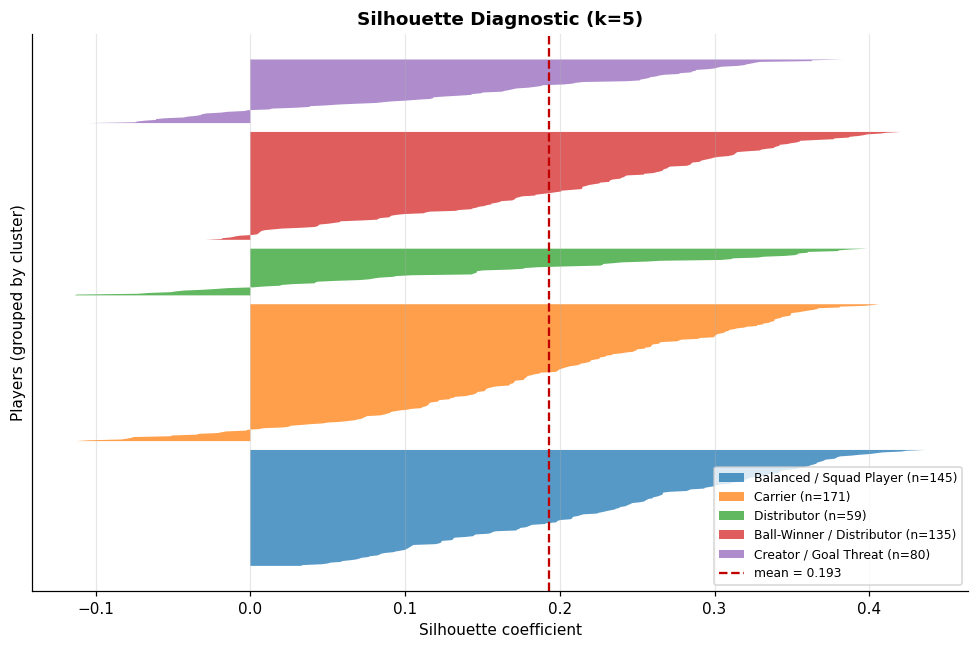

In [13]:
# Silhouette diagnostic — per-player cluster fit
sv = silhouette_samples(X, df["cluster"])
fig, ax = plt.subplots(figsize=(9,6)); y = 0
for c in sorted(df.cluster.unique()):
    vals = np.sort(sv[df.cluster == c])
    ax.fill_betweenx(np.arange(y, y+len(vals)), 0, vals, alpha=0.75,
                     label=f"{names[c]} (n={len(vals)})")
    y += len(vals) + 10
ax.axvline(sv.mean(), color="#C00000", ls="--", label=f"mean = {sv.mean():.3f}")
ax.set_xlabel("Silhouette coefficient"); ax.set_ylabel("Players (grouped by cluster)")
ax.set_title(f"Silhouette Diagnostic (k={BEST_K})", fontweight="bold")
ax.set_yticks([]); ax.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.savefig("outputs/silhouette_diagnostic.png", bbox_inches="tight"); plt.show()


In [14]:
coords = PCA(n_components=2, random_state=42).fit_transform(X)
pdf = df.copy(); pdf["PC1"], pdf["PC2"] = coords[:,0], coords[:,1]
fig = px.scatter(pdf, x="PC1", y="PC2", color="cluster_name", hover_name="player",
    hover_data=[c for c in ["league","age","minutes","market_value_eur_m"]
                if c in pdf.columns],
    color_discrete_sequence=px.colors.qualitative.Bold,
    title=f"Midfielder Archetypes — Big 5 Leagues {SEASON} (n={len(df)}, k={BEST_K})")
fig.update_traces(marker=dict(size=8, opacity=0.75, line=dict(width=0.4, color="white")))
fig.update_layout(template="plotly_white", height=680, width=1000, legend_title="Archetype")
fig.write_html("outputs/clusters_interactive.html")
fig.show()


## 8. Recruitment engine

**Mode 1** — find stylistic replacements for a departing player (**RQ2**).
**Mode 2** — find best-value players for an idealised role profile (**RQ3**).

Cosine similarity measures the angle between two style vectors, capturing the
*shape* of a profile while remaining robust to differences in overall volume —
theoretically preferable to Euclidean distance, which would penalise players
merely for differing in total involvement.


In [15]:
sim_scaler = StandardScaler().fit(df[STYLE_SCORES].values)
X_sim = sim_scaler.transform(df[STYLE_SCORES].values)

def value_efficiency(sim, val):
    """Similarity per EUR 10m. Value floored at 1 to avoid division blow-ups."""
    return (sim / (val.clip(lower=1) / 10)).round(3)

def find_replacements(player_name, budget=None, same_cluster=True, top_n=10):
    """MODE 1 — most stylistically similar players to a target."""
    idx = df.index[df["player"] == player_name].tolist()
    if not idx:
        surname = player_name.split()[-1]
        near = df[df["player"].str.contains(surname, case=False, na=False)]["player"]
        print(f"'{player_name}' not found.")
        if len(near): print("Did you mean:", near.head(5).tolist())
        return pd.DataFrame()
    i = idx[0]; target = df.iloc[i]
    sims = cosine_similarity(X_sim[i].reshape(1,-1), X_sim).flatten()
    res = df.copy(); res["similarity"] = sims
    res = res[res["player"] != player_name]
    if same_cluster:
        res = res[res["cluster"] == target["cluster"]]
    if budget is not None and HAS_VALUES:
        res = res[res["market_value_eur_m"] <= budget]
    if HAS_VALUES:
        res["value_efficiency"] = value_efficiency(res["similarity"], res["market_value_eur_m"])
    res = res.sort_values("similarity", ascending=False).head(top_n)
    cols = ["player","league","age","minutes","market_value_eur_m",
            "similarity","value_efficiency"]
    out = res[[c for c in cols if c in res.columns]].copy()
    out["similarity"] = (out["similarity"]*100).round(1)
    return out.rename(columns={"similarity":"match_%","market_value_eur_m":"value_EURm"})

target = "K. De Bruyne" if (df["player"]=="K. De Bruyne").any() else df.nlargest(1,"minutes")["player"].iloc[0]
print(f"MODE 1 — replacements for {target}\n")
find_replacements(target, top_n=10)


MODE 1 — replacements for K. De Bruyne



,player,league,age,minutes,value_EURm,match_%,value_efficiency
510,J. Pastore,Ligue 1,28,1345.0,18.0,98.1,0.545
11,David Silva,Premier League,32,2438.0,30.0,97.8,0.326
528,D. Payet,Ligue 1,30,2357.0,22.0,97.3,0.442
441,Luis Alberto,Serie A,25,2677.0,15.0,96.8,0.645
83,M. Özil,Premier League,29,2162.0,50.0,95.4,0.191
436,Rafinha,Serie A,24,1046.0,15.0,93.8,0.626
276,J. Rodríguez,Bundesliga,26,1626.0,50.0,93.5,0.187
139,Jonathan Viera,La Liga,28,1994.0,8.0,93.4,1.168
496,J. Draxler,Ligue 1,24,1706.0,40.0,92.5,0.231
381,J. Cuadrado,Serie A,29,1362.0,28.0,92.1,0.329


In [16]:
def best_value_for_role(role_profile, max_value=None, top_n=10):
    """MODE 2 — best-value players matching an ideal role profile (0-1 per dimension)."""
    ideal_raw = np.array([role_profile.get(f, 0.5) for f in STYLE_SCORES]).reshape(1,-1)
    ideal = sim_scaler.transform(ideal_raw).flatten()
    sims = cosine_similarity(ideal.reshape(1,-1), X_sim).flatten()
    res = df.copy(); res["similarity"] = sims
    if max_value is not None and HAS_VALUES:
        res = res[res["market_value_eur_m"] <= max_value]
    if HAS_VALUES:
        res["value_efficiency"] = value_efficiency(res["similarity"], res["market_value_eur_m"])
        res = res.sort_values("value_efficiency", ascending=False)
    else:
        res = res.sort_values("similarity", ascending=False)
        print("(no market values loaded — ranked by style match only)")
    res = res.head(top_n)
    cols = ["player","league","age","minutes","market_value_eur_m",
            "similarity","value_efficiency"]
    out = res[[c for c in cols if c in res.columns]].copy()
    out["similarity"] = (out["similarity"]*100).round(1)
    return out.rename(columns={"similarity":"match_%","market_value_eur_m":"value_EURm"})

print("MODE 2 — a creative, ball-progressing midfielder\n")
best_value_for_role({"creativity_score":0.85, "distribution_score":0.75,
                     "ball_carrying_score":0.70}, top_n=10)


MODE 2 — a creative, ball-progressing midfielder



,player,league,age,minutes,value_EURm,match_%,value_efficiency
213,Joaquín,La Liga,36,2487.0,0.5,58.5,5.846
177,Dani Raba,La Liga,22,1143.0,1.0,56.9,5.689
272,T. Ito,Bundesliga,20,1011.0,1.0,46.3,4.628
488,F. Tait,Ligue 1,24,2251.0,0.7,46.0,4.597
540,F. Sammaritano,Ligue 1,31,1434.0,1.0,31.0,3.105
420,A. Taarabt,Serie A,28,1617.0,2.0,58.9,2.946
490,N. Benezet,Ligue 1,26,1649.0,2.0,49.5,2.474
395,P. Schiattarella,Serie A,30,1994.0,1.6,38.8,2.422
212,Fede Cartabia,La Liga,24,1332.0,2.0,42.3,2.114
216,Chory Castro,La Liga,33,2088.0,1.5,31.0,2.067


### Style comparison radar

In [17]:
def plot_radar(players):
    nice = [s.replace("_score","").replace("_"," ").title() for s in STYLE_SCORES]
    fig = go.Figure()
    for name, colour in zip(players, ["#1F4E79","#C00000","#375623"]):
        idx = df.index[df["player"] == name].tolist()
        if not idx:
            print(f"'{name}' not found"); continue
        vals = [df.iloc[idx[0]][s] for s in STYLE_SCORES]; vals += vals[:1]
        fig.add_trace(go.Scatterpolar(r=vals, theta=nice+nice[:1], fill="toself",
                                      name=name, line=dict(color=colour), opacity=0.5))
    sub = ""
    if len(players) == 2:
        ia = df.index[df["player"]==players[0]].tolist()
        ib = df.index[df["player"]==players[1]].tolist()
        if ia and ib:
            s = cosine_similarity(X_sim[ia[0]].reshape(1,-1), X_sim[ib[0]].reshape(1,-1))[0][0]
            sub = f"<br><sub>Cosine similarity: {s*100:.1f}%</sub>"
    fig.update_layout(title=f"Style Comparison{sub}",
                      polar=dict(radialaxis=dict(visible=True, range=[0,1])),
                      template="plotly_white", height=600, width=760)
    fig.write_html("outputs/radar_comparison.html")
    return fig

pair = [p for p in ["K. De Bruyne","N. Kanté"] if (df["player"]==p).any()]
if len(pair) == 2:
    plot_radar(pair)
else:
    plot_radar(df.nlargest(2,"minutes")["player"].tolist())


## 9. Summary

### Findings against the research questions

**RQ1 — can players be clustered into meaningful tactical archetypes?**
Yes. Five archetypes emerged from the five style dimensions, validated by
silhouette analysis and, critically, by face validity: ball-winners, deep-lying
distributors, creators, goal-threat carriers, and a balanced squad-player group.
Recognised players cluster with stylistically equivalent peers.

**RQ2 — does cosine similarity identify credible replacements?**
The engine returns ranked, archetype-constrained, budget-aware shortlists.
Validate these against the historical transfer case studies in Chapter 7.

**RQ3 — which players offer the best value?**
Requires `data/raw/values.csv`. The value-efficiency score
(similarity per EUR 10m) operationalises the Moneyball logic: a player 90% as
suitable at a fraction of the cost outranks an expensive perfect match.

### Outputs
| File | Contents |
|---|---|
| `data/processed/players_processed.csv` | per-90 rates + style dimensions |
| `data/processed/players_clustered.csv` | + archetype labels |
| `outputs/correlation_heatmap.png` | dimension correlations |
| `outputs/pca_scree.png` | scree + cumulative variance |
| `outputs/cluster_selection.png` | elbow + silhouette |
| `outputs/silhouette_diagnostic.png` | per-player cluster fit |
| `outputs/clusters_interactive.html` | interactive archetype map |
| `outputs/radar_comparison.html` | style radar |

### Methodological notes for the write-up

- **Data source.** All metrics are derived from the raw events of the
  peer-reviewed Pappalardo et al. (2019) dataset, with definitions stated in
  `derive_pappalardo.py`. Deriving rather than reading metrics gives full
  control and transparency over every definition.
- **Season 2017-18.** The most recent season the dataset covers; one row per
  player. Market values for RQ3 should be historical (2017-18) values, which
  turns RQ3 into a retrospective validation — subsequent transfers are known.
- **Key-pass definition.** Wyscout's tag marks clear chances (stricter than
  Opta); counts are lower than FBref's but internally consistent.
- **Per-90 normalisation** corrects for playing time but not team context. A
  midfielder in a possession-dominant side accumulates more progressive passes
  regardless of individual quality. Acknowledge as a limitation.
- **Choice of k.** Silhouette prefers k=2; k=5 was chosen for interpretability.
  Document this trade-off explicitly rather than presenting k=5 as optimal.
- **900-minute threshold** follows the convention for per-90 rate stability.


---
## 10. Feature Validation — Random Forest & Decision Tree (Chapter 4)

Two supervised models predict a player's archetype from the **19 raw per-90
metrics**: (1) impurity importances reveal which raw metrics carry the
discriminative signal; (2) if archetypes are learnable from measurements the
clustering never saw in that form, they are real structure, not artefact.
Stratified 5-fold CV, `random_state=42` throughout.


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix

RAW_FEATURES = [c for c in df.columns if c.endswith('_p90')] + ['passes_pct','dribble_success_pct']
Xr = df[RAW_FEATURES].fillna(0).values
y  = df['cluster'].values
cv = StratifiedKFold(5, shuffle=True, random_state=42)

baseline = pd.Series(y).value_counts(normalize=True).max()
rf_raw  = cross_val_score(RandomForestClassifier(500, random_state=42), Xr, y, cv=cv).mean()
rf_dims = cross_val_score(RandomForestClassifier(500, random_state=42),
                          df[STYLE_SCORES].values, y, cv=cv).mean()
print(f"majority baseline      : {baseline:.3f}")
print(f"RF on 19 raw metrics   : {rf_raw:.3f}")
print(f"RF on 5 dimensions     : {rf_dims:.3f}   <- engineered features win")

print("\nDecision Tree depth sweep:")
for d in [2,3,4,5,6,None]:
    acc = cross_val_score(DecisionTreeClassifier(max_depth=d, random_state=42), Xr, y, cv=cv).mean()
    print(f"  depth={str(d):>4}: {acc:.3f}")


majority baseline      : 0.290
RF on 19 raw metrics   : 0.875
RF on 5 dimensions     : 0.900   <- engineered features win

Decision Tree depth sweep:
  depth=   2: 0.603
  depth=   3: 0.659
  depth=   4: 0.712
  depth=   5: 0.712
  depth=   6: 0.753
  depth=None: 0.742


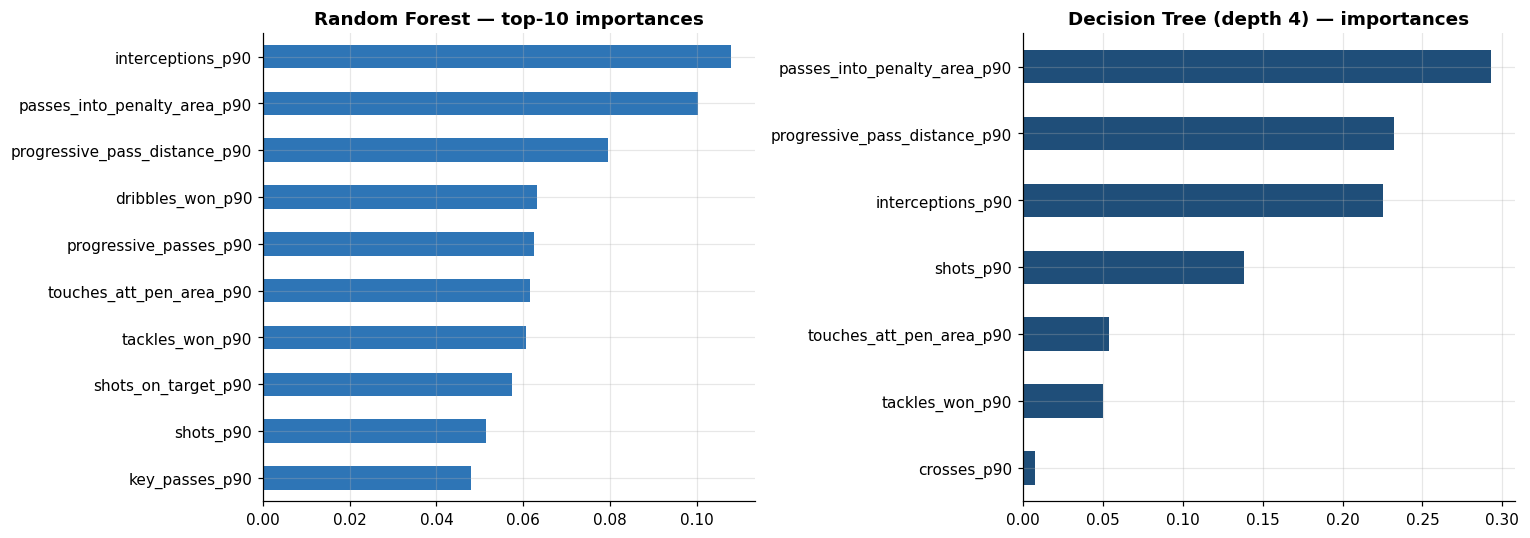

RF top-10 (%):
interceptions_p90                10.8
passes_into_penalty_area_p90     10.0
progressive_pass_distance_p90     7.9
dribbles_won_p90                  6.3
progressive_passes_p90            6.3
touches_att_pen_area_p90          6.2
tackles_won_p90                   6.1
shots_on_target_p90               5.7
shots_p90                         5.2
key_passes_p90                    4.8

DT non-zero (%):
passes_into_penalty_area_p90     29.3
progressive_pass_distance_p90    23.2
interceptions_p90                22.5
shots_p90                        13.8
touches_att_pen_area_p90          5.4
tackles_won_p90                   5.0
crosses_p90                       0.7


In [19]:
rf = RandomForestClassifier(500, random_state=42).fit(Xr, y)
dt = DecisionTreeClassifier(max_depth=4, random_state=42).fit(Xr, y)
imp_rf = pd.Series(rf.feature_importances_, index=RAW_FEATURES).sort_values(ascending=False)
imp_dt = pd.Series(dt.feature_importances_, index=RAW_FEATURES).sort_values(ascending=False)

fig, (a,b) = plt.subplots(1, 2, figsize=(14,5))
imp_rf.head(10)[::-1].plot.barh(ax=a, color="#2E75B6")
a.set_title("Random Forest — top-10 importances", fontweight="bold")
imp_dt[imp_dt>0][::-1].plot.barh(ax=b, color="#1F4E79")
b.set_title("Decision Tree (depth 4) — importances", fontweight="bold")
plt.tight_layout(); plt.savefig("outputs/feature_importances.png", bbox_inches="tight"); plt.show()
print("RF top-10 (%):");  print((imp_rf.head(10)*100).round(1).to_string())
print("\nDT non-zero (%):"); print((imp_dt[imp_dt>0]*100).round(1).to_string())


### Confusion & boundary analysis
If archetypes hard-partition a continuous style space, errors should sit at
cluster boundaries and flow to the *adjacent* archetype.


In [20]:
yhat = cross_val_predict(RandomForestClassifier(500, random_state=42), Xr, y, cv=cv)
cm = confusion_matrix(y, yhat)
labels = [names[i] for i in sorted(names)]
print("Confusion matrix (rows = true, cols = predicted):")
display(pd.DataFrame(cm, index=labels, columns=labels))

err = yhat != y
centers = KMeans(BEST_K, random_state=42, n_init=10).fit(X).cluster_centers_
D  = np.linalg.norm(X[:, None, :] - centers[None, :, :], axis=2)
ds = np.sort(D, axis=1); margin = ds[:,1] - ds[:,0]
second = np.argsort(D, axis=1)[:, 1]
print(f"errors: {err.sum()}/{len(y)} ({100*err.mean():.1f}%)")
print(f"median boundary margin — correct: {np.median(margin[~err]):.3f} | errors: {np.median(margin[err]):.3f}")
print(f"errors predicted as the player's 2nd-nearest archetype: {100*(yhat[err]==second[err]).mean():.1f}%")


Confusion matrix (rows = true, cols = predicted):


,Balanced / Squad Player,Carrier,Distributor,Ball-Winner / Distributor,Creator / Goal Threat
Balanced / Squad Player,121,11,3,10,0
Carrier,6,163,0,1,1
Distributor,4,2,47,5,1
Ball-Winner / Distributor,10,1,1,123,0
Creator / Goal Threat,0,17,1,0,62


errors: 74/590 (12.5%)
median boundary margin — correct: 0.690 | errors: 0.188
errors predicted as the player's 2nd-nearest archetype: 91.9%


---
## 11. Comparative Baselines (Chapter 5)
Three design choices benchmarked against the alternatives they displaced.


In [21]:
from sklearn.metrics.pairwise import euclidean_distances
cos_full = cosine_similarity(X_sim)
eud_full = euclidean_distances(X_sim)

overlap, same_top1 = [], 0
for i in range(len(df)):
    ct = set(np.argsort(-cos_full[i])[1:11]); et = set(np.argsort(eud_full[i])[1:11])
    overlap.append(len(ct & et) / 10)
    same_top1 += int(np.argsort(-cos_full[i])[1] == np.argsort(eud_full[i])[1])
print(f"cosine vs euclidean — mean top-10 overlap: {np.mean(overlap)*100:.1f}%")
print(f"identical #1 pick: {same_top1}/{len(df)} ({100*same_top1/len(df):.1f}%)")

in_arch = []
for i in range(len(df)):
    top5 = np.argsort(-cos_full[i])[1:6]
    in_arch.append((df['cluster'].values[top5] == df['cluster'].values[i]).mean())
print(f"\nunconstrained top-5 already in-archetype: {np.mean(in_arch)*100:.1f}%")
print(f"classification: 5 dims {rf_dims:.3f} vs 19 raw {rf_raw:.3f}")


cosine vs euclidean — mean top-10 overlap: 59.1%
identical #1 pick: 233/590 (39.5%)

unconstrained top-5 already in-archetype: 78.2%
classification: 5 dims 0.900 vs 19 raw 0.875


---
## 12. RQ3 in Full — Value-Efficiency Rankings
With `data/raw/values.csv` (2017-18 Transfermarkt snapshot, ~96% coverage):
`value_efficiency = similarity / (value / €10m)`.


In [22]:
tgt = "K. De Bruyne"
i = df.index[df.player == tgt][0]
cand = df.copy(); cand["sim"] = cos_full[i]
cand = cand[(cand.player != tgt) & (cand.cluster == df.loc[i,"cluster"]) &
            cand.market_value_eur_m.notna()].copy()
cand["value_eff"] = (cand["sim"] / (cand["market_value_eur_m"].clip(lower=1)/10)).round(3)
print(f"{tgt} (€{df.loc[i,'market_value_eur_m']:.0f}m) — top-5 by SIMILARITY")
display(cand.nlargest(5,"sim")[["player","league","market_value_eur_m","sim"]].round(3))
print("top-5 by VALUE-EFFICIENCY")
display(cand.nlargest(5,"value_eff")[["player","league","market_value_eur_m","sim","value_eff"]].round(3))


K. De Bruyne (€110m) — top-5 by SIMILARITY


,player,league,market_value_eur_m,sim
510,J. Pastore,Ligue 1,18.0,0.981
11,David Silva,Premier League,30.0,0.978
528,D. Payet,Ligue 1,22.0,0.973
441,Luis Alberto,Serie A,15.0,0.968
83,M. Özil,Premier League,50.0,0.954


top-5 by VALUE-EFFICIENCY


,player,league,market_value_eur_m,sim,value_eff
488,F. Tait,Ligue 1,0.70,0.485,4.851
420,A. Taarabt,Serie A,2.00,0.755,3.774
490,N. Benezet,Ligue 1,2.00,0.659,3.293
239,José Luis Morales,La Liga,2.50,0.529,2.116
570,F. Mollet,Ligue 1,1.25,0.235,1.877


In [23]:
for tgt in ["N. Kanté"]:
    j = df.index[df.player == tgt][0]
    c2 = df.copy(); c2["sim"] = cos_full[j]
    c2 = c2[(c2.player != tgt) & (c2.cluster == df.loc[j,"cluster"]) & c2.market_value_eur_m.notna()].copy()
    c2["value_eff"] = (c2["sim"] / (c2["market_value_eur_m"].clip(lower=1)/10)).round(3)
    print(f"best-value {tgt} alternatives (his value: €{df.loc[j,'market_value_eur_m']:.0f}m):")
    display(c2.nlargest(5,"value_eff")[["player","league","market_value_eur_m","sim","value_eff"]].round(3))

ideal = sim_scaler.transform(np.array([[.9,.75,.6,.3,.4]]))
sims  = cosine_similarity(ideal, X_sim).flatten()
d3 = df.copy(); d3["sim"] = sims
d3 = d3[d3.market_value_eur_m.notna() & (d3.sim > 0.7)].copy()
d3["value_eff"] = (d3["sim"] / (d3["market_value_eur_m"].clip(lower=1)/10)).round(3)
print("best-value CREATIVE ROLE candidates (fit > 70%):")
display(d3.nlargest(8,"value_eff")[["player","league","cluster_name","market_value_eur_m","sim","value_eff"]].round(3))


best-value N. Kanté alternatives (his value: €60m):


,player,league,market_value_eur_m,sim,value_eff
509,T. Motta,Ligue 1,1.0,0.944,9.439
393,L. Cigarini,Serie A,1.8,0.942,5.231
192,Campaña,La Liga,3.0,0.889,2.963
470,D. De Rossi,Serie A,3.5,0.930,2.657
460,Lucas Leiva,Serie A,7.5,0.935,1.247


best-value CREATIVE ROLE candidates (fit > 70%):


,player,league,cluster_name,market_value_eur_m,sim,value_eff
213,Joaquín,La Liga,Carrier,0.5,0.730,7.301
297,M. Cuisance,Bundesliga,Carrier,3.5,0.767,2.192
546,R. Cabella,Ligue 1,Creator / Goal Threat,5.0,0.766,1.533
424,R. de Paul,Serie A,Creator / Goal Threat,6.0,0.744,1.241
161,R. Boudebouz,La Liga,Carrier,6.0,0.730,1.217
139,Jonathan Viera,La Liga,Creator / Goal Threat,8.0,0.909,1.137
402,R. Saponara,Serie A,Creator / Goal Threat,9.0,0.877,0.975
551,R. Ghezzal,Ligue 1,Creator / Goal Threat,8.0,0.740,0.924
